<a href="https://colab.research.google.com/github/afullhart/SantaRita/blob/main/Widgets/NRI_Sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f

# High Bare Ground Functions and Widget

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# Geometry Generation Functions
# ==========================================
def create_irregular_shrub(center_x, center_y, base_radius, num_points=12):
    """Generates an irregular polygon to represent a shrub."""
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for angle in angles:
        # Perturb the radius by +/- 40% to make it irregular
        r = base_radius * np.random.uniform(0.6, 1.4)
        points.append((center_x + r * np.cos(angle), center_y + r * np.sin(angle)))
    return Polygon(points)

def generate_random_shrubs(num_shrubs=60, plot_radius=55): # UPDATED: 60 shrubs
    """Generates a list of randomly placed shrub polygons within the plot."""
    shrubs = []

    # UPDATED: Max shrub radius is now 5m
    max_shrub_radius = 5.0
    generation_radius = plot_radius + max_shrub_radius

    for _ in range(num_shrubs):
        # UPDATED: Random radius between 1m and 5m (Average = 3m)
        radius = np.random.uniform(1.0, 5.0)

        # Uniform distribution up to 60m
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)

        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shrubs.append(create_irregular_shrub(x, y, radius))
    return shrubs

def get_nri_spokes(hub_radius=5, plot_radius=55):
    """Generates the 3 NRI transect lines at 0, 120, and 240 degrees."""
    angles = [0, 120, 240]
    spokes = []
    for a in angles:
        rad = np.radians(a)
        x1, y1 = hub_radius * np.cos(rad), hub_radius * np.sin(rad)
        x2, y2 = plot_radius * np.cos(rad), plot_radius * np.sin(rad)
        spokes.append(LineString([(x1, y1), (x2, y2)]))
    return spokes

# ==========================================
# Main Simulation Class
# ==========================================
class NRISimulation:
    def __init__(self):
        self.plot_radius = 55
        self.hub_radius = 5
        self.plot_circle = Point(0, 0).buffer(self.plot_radius)
        self.spokes = get_nri_spokes(self.hub_radius, self.plot_radius)
        self.total_transect_length = 3 * (self.plot_radius - self.hub_radius) # 150m
        self.shrubs = []
        self.shrub_union = None

        # Output widget for matplotlib to prevent cell output spam
        self.out = widgets.Output()

        # Setup UI FIRST so the dropdown attribute exists before plotting
        self.setup_ui()

        # Generate initial data (this calls update_plot internally)
        self.generate_new_shapes()

    def generate_new_shapes(self, b=None):
        """Creates entirely new shrub geometries and positions."""
        self.shrubs = generate_random_shrubs(60, self.plot_radius) # UPDATED: 60 shrubs
        self.shrub_union = unary_union(self.shrubs)
        self.update_plot()

    def randomize_positions(self, b=None):
        """Moves existing shrubs to new locations."""
        new_shrubs = []

        # UPDATED: Expand generation area by max shrub radius (5.0m)
        generation_radius = self.plot_radius + 5.0

        for shrub in self.shrubs:
            # Calculate current centroid
            cx, cy = shrub.centroid.x, shrub.centroid.y

            # Generate new random position (Uniform distribution up to 60m)
            r = generation_radius * np.sqrt(np.random.uniform(0, 1))
            theta = np.random.uniform(0, 2 * np.pi)

            new_cx, new_cy = r * np.cos(theta), r * np.sin(theta)

            # Translate polygon
            from shapely.affinity import translate
            new_shrub = translate(shrub, xoff=(new_cx - cx), yoff=(new_cy - cy))
            new_shrubs.append(new_shrub)

        self.shrubs = new_shrubs
        self.shrub_union = unary_union(self.shrubs)
        self.update_plot()

    def setup_ui(self):
        self.protocol_dropdown = widgets.Dropdown(
            options=[
                ('0m (Continuous Line)', 0.0),
                ('0.25m (Point Intercept)', 0.25),
                ('0.50m (Point Intercept)', 0.50),
                ('1.00m (Point Intercept)', 1.00),
                ('2.00m (Point Intercept)', 2.00)
            ],
            value=0.0,
            description='Protocol:'
        )
        self.protocol_dropdown.observe(lambda change: self.update_plot() if change['name'] == 'value' else None)

        self.btn_randomize = widgets.Button(description="Randomize Positions", button_style='info')
        self.btn_randomize.on_click(self.randomize_positions)

        self.btn_new_shapes = widgets.Button(description="Generate New Shrubs", button_style='warning')
        self.btn_new_shapes.on_click(self.generate_new_shapes)

        controls = widgets.HBox([self.protocol_dropdown, self.btn_randomize, self.btn_new_shapes])
        display(widgets.VBox([controls, self.out]))

    def update_plot(self):
        with self.out:
            clear_output(wait=True)
            interval = self.protocol_dropdown.value

            # 1. Calculate True Bare Ground
            # Clip shrubs to plot boundary just in case they stick out (Handles spill-over!)
            shrubs_in_plot = self.shrub_union.intersection(self.plot_circle)
            true_bare_area = self.plot_circle.area - shrubs_in_plot.area
            true_bg_pct = (true_bare_area / self.plot_circle.area) * 100

            # 2. Plotting setup
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.set_aspect('equal')
            ax.set_facecolor('#f0f0f0')
            ax.axis('off')

            # Draw plot boundary and hub
            plot_patch = plt.Circle((0, 0), self.plot_radius, color='white', ec='black', lw=2)
            hub_patch = plt.Circle((0, 0), self.hub_radius, color='#e0e0e0', ec='black', lw=1, ls='--')
            ax.add_patch(plot_patch)
            ax.add_patch(hub_patch)

            # Draw Shrubs (Including those just outside the boundary)
            if self.shrub_union.geom_type == 'Polygon':
                geoms = [self.shrub_union]
            else:
                geoms = self.shrub_union.geoms

            for geom in geoms:
                x, y = geom.exterior.xy
                ax.fill(x, y, alpha=0.5, fc='forestgreen', ec='darkgreen', lw=1.5)

            # 3. Calculate Sampled Bare Ground & Draw Sampling Tools
            sampled_bg_pct = 0

            if interval == 0.0: # Continuous Line Intercept
                total_intercept = 0
                for spoke in self.spokes:
                    # Draw base spoke
                    x, y = spoke.xy
                    ax.plot(x, y, color='gray', lw=2, zorder=3)

                    # Intersect with shrubs
                    intersection = spoke.intersection(self.shrub_union)
                    total_intercept += intersection.length

                    # Highlight intersections
                    if not intersection.is_empty:
                        if intersection.geom_type == 'LineString':
                            ix, iy = intersection.xy
                            ax.plot(ix, iy, color='red', lw=3, zorder=4)
                        elif intersection.geom_type == 'MultiLineString':
                            for line in intersection.geoms:
                                ix, iy = line.xy
                                ax.plot(ix, iy, color='red', lw=3, zorder=4)

                sampled_bg_pct = (1 - (total_intercept / self.total_transect_length)) * 100

            else: # Point Intercept
                total_points = 0
                bare_points = 0

                # Draw faint lines for context
                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='lightgray', lw=1, zorder=2)

                # Generate and test points
                for spoke in self.spokes:
                    # spoke length is 50m
                    for d in np.arange(0, 50.001, interval):
                        pt = spoke.interpolate(d)
                        total_points += 1

                        if self.shrub_union.contains(pt):
                            ax.plot(pt.x, pt.y, 'ro', markersize=4, zorder=4) # Shrub hit
                        else:
                            ax.plot(pt.x, pt.y, 'ko', markersize=3, zorder=4) # Bare ground hit
                            bare_points += 1

                sampled_bg_pct = (bare_points / total_points) * 100 if total_points > 0 else 0

            # 4. Display Metrics
            error = sampled_bg_pct - true_bg_pct

            title_text = (
                f"True Bare Ground: {true_bg_pct:.2f}%\n"
                f"Sampled Bare Ground: {sampled_bg_pct:.2f}%\n"
            )

            # Color code the error text based on severity
            color = 'black'
            if abs(error) > 5: color = 'darkorange'
            if abs(error) > 10: color = 'red'

            plt.title(title_text, fontsize=14, pad=15)
            plt.figtext(0.5, 0.05, f"Error (Bias): {error:+.2f}%", ha="center", fontsize=16, fontweight='bold', color=color)

            plt.xlim(-70, 70) # Expanded view to see spill-over shrubs
            plt.ylim(-70, 70)
            plt.tight_layout()
            plt.show()

# Run the simulation
simulation = NRISimulation()


### All intervals figure

--- STATISTICAL SUMMARY (HIGH BARE GROUND) ---
Protocol: 0m (Continuous Line)
  Mean Bias: -0.1177% | MAE: 5.3606% | Std Dev: 6.6989%

Protocol: 0.25m (Point Intercept)
  Mean Bias: -0.1093% | MAE: 5.3464% | Std Dev: 6.6839%

Protocol: 0.50m (Point Intercept)
  Mean Bias: -0.0916% | MAE: 5.3350% | Std Dev: 6.6717%

Protocol: 1.00m (Point Intercept)
  Mean Bias: -0.0901% | MAE: 5.3039% | Std Dev: 6.6268%

Protocol: 2.00m (Point Intercept)
  Mean Bias: -0.0616% | MAE: 5.3396% | Std Dev: 6.6753%



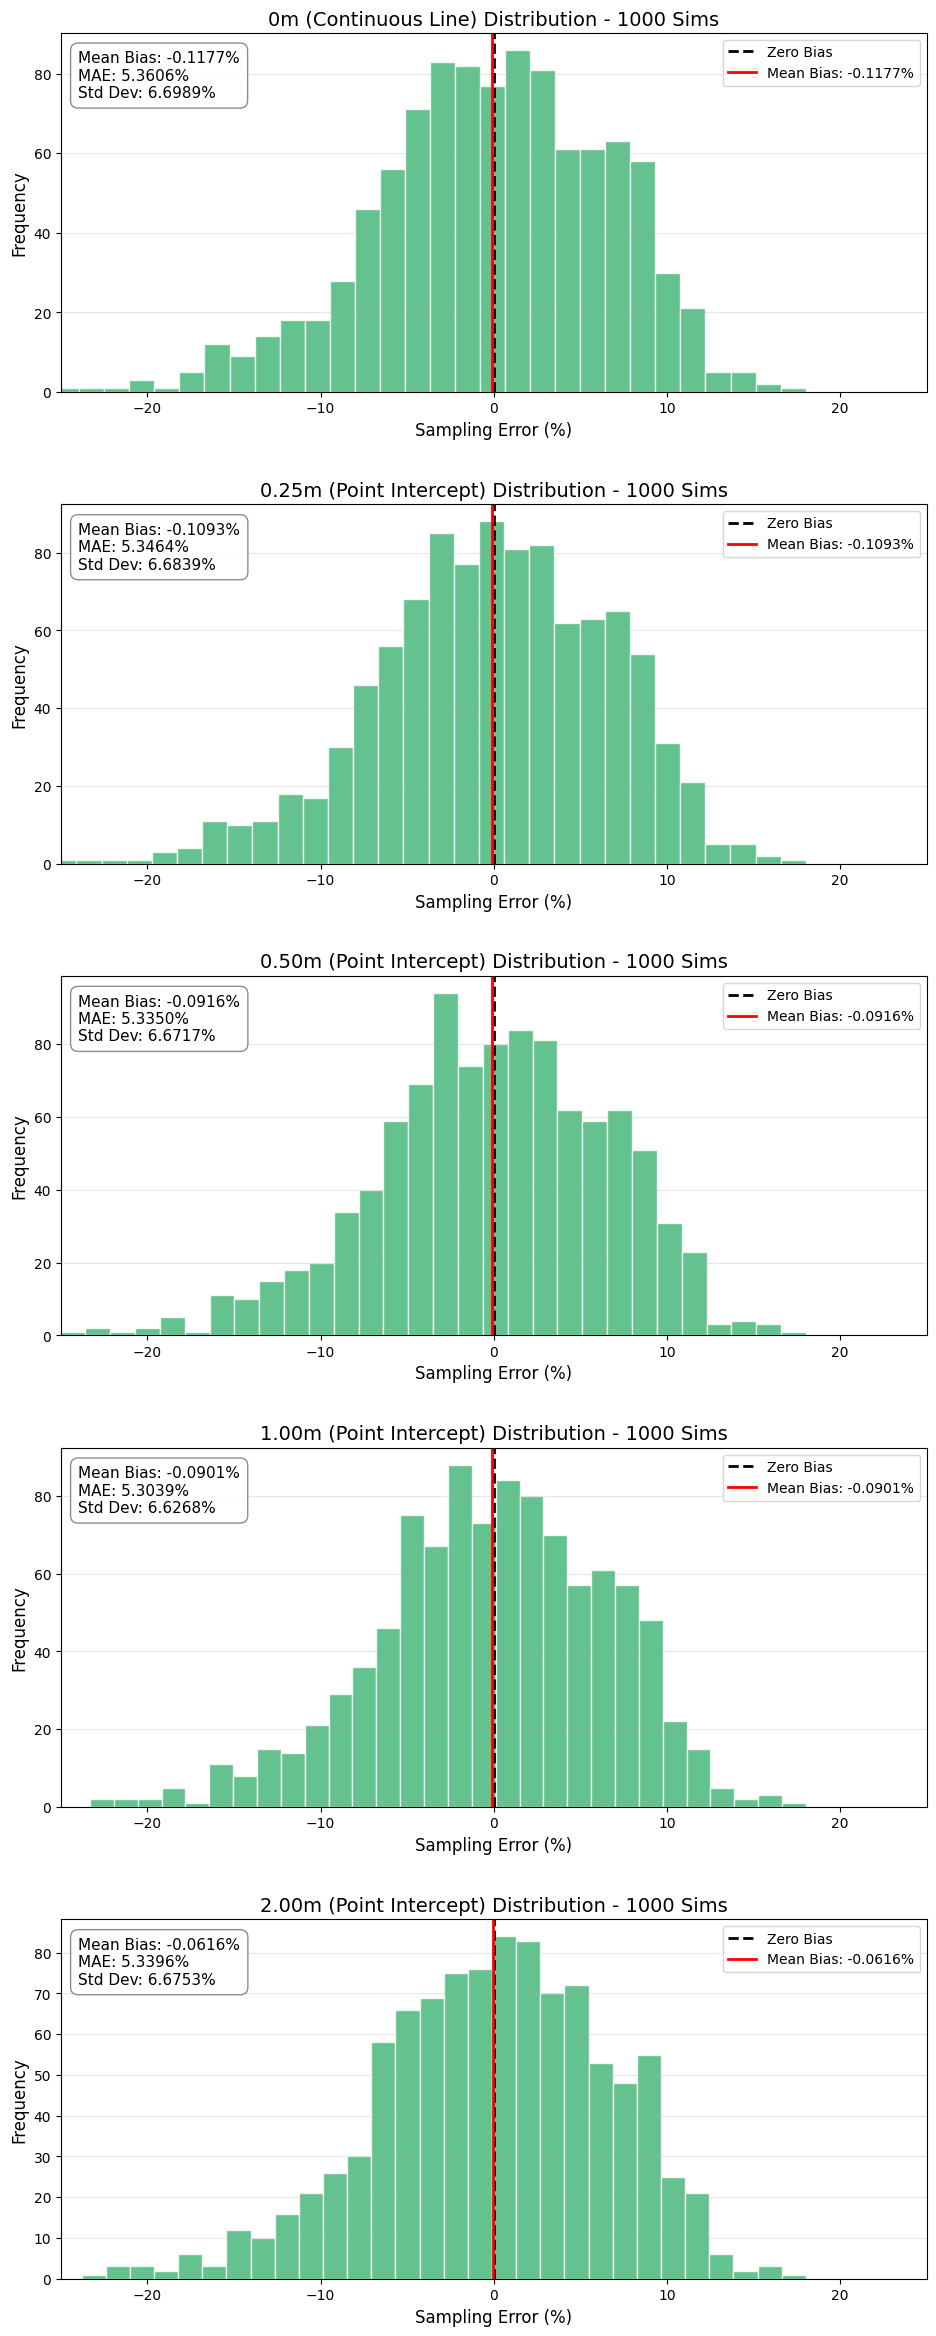

In [2]:
# ==========================================
# BLOCK 2: Headless Validation (All Scales)
# ==========================================
from shapely.geometry import MultiPoint

def run_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the NRI sampling logic headless across multiple sampling scales."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)
    spoke_length = plot_radius - hub_radius

    intervals = [0.0, 0.25, 0.50, 1.00, 2.00]
    interval_names = {0.0: '0m (Continuous Line)', 0.25: '0.25m (Point Intercept)',
                      0.50: '0.50m (Point Intercept)', 1.00: '1.00m (Point Intercept)',
                      2.00: '2.00m (Point Intercept)'}

    # Store errors for each protocol
    errors = {i: [] for i in intervals}

    print(f"Crunching {num_iterations} simulations across {len(intervals)} scales... please wait.")

    # OPTIMIZATION: Pre-calculate MultiPoint geometries for the point intercept intervals
    # Since the spokes don't move, the sampling coordinates are identical every iteration.
    sampling_points = {}
    for interval in intervals[1:]:
        pts = []
        for spoke in spokes:
            for d in np.arange(0, spoke_length + 0.001, interval):
                pts.append(spoke.interpolate(d))
        sampling_points[interval] = MultiPoint(pts)

    for i in range(num_iterations):
        # 1. Generate new shrubs (60 shrubs, 3m average radius)
        shrubs = generate_random_shrubs(60, plot_radius)
        shrub_union = unary_union(shrubs)

        # 2. Calculate True Bare Ground
        shrubs_in_plot = shrub_union.intersection(plot_circle)
        true_bare_area = plot_circle.area - shrubs_in_plot.area
        true_bg_pct = (true_bare_area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground for each protocol
        for interval in intervals:
            if interval == 0.0: # Continuous Line
                total_intercept = sum(spoke.intersection(shrub_union).length for spoke in spokes)
                sampled_bg_pct = (1 - (total_intercept / total_transect_length)) * 100
            else: # Point Intercept
                # Intersect pre-calculated points with the shrub union
                hits = sampling_points[interval].intersection(shrub_union)
                if hits.is_empty:
                    shrub_hits = 0
                elif hits.geom_type == 'Point':
                    shrub_hits = 1
                else:
                    shrub_hits = len(hits.geoms)

                total_pts = len(sampling_points[interval].geoms)
                bare_hits = total_pts - shrub_hits
                sampled_bg_pct = (bare_hits / total_pts) * 100 if total_pts > 0 else 0

            # 4. Record Error
            errors[interval].append(sampled_bg_pct - true_bg_pct)

    # --- Visualize Results ---
    from IPython.display import clear_output
    clear_output(wait=True)

    fig, axes = plt.subplots(5, 1, figsize=(10, 24))
    print("--- STATISTICAL SUMMARY (HIGH BARE GROUND) ---")

    for idx, interval in enumerate(intervals):
        ax = axes[idx]
        errs = errors[interval]
        mean_error = np.mean(errs)
        std_dev = np.std(errs)
        mae = np.mean(np.abs(errs))

        # Print stats directly to console
        print(f"Protocol: {interval_names[interval]}")
        print(f"  Mean Bias: {mean_error:+.4f}% | MAE: {mae:.4f}% | Std Dev: {std_dev:.4f}%\n")

        # Plot Histogram
        ax.hist(errs, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
        ax.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

        ax.set_title(f"{interval_names[interval]} Distribution - {num_iterations} Sims", fontsize=14)
        ax.set_xlabel("Sampling Error (%)", fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(-25, 25) # Standardized X-axis for visual comparison

        # Draw Stats Box
        stats_text = (f"Mean Bias: {mean_error:+.4f}%\n"
                      f"MAE: {mae:.4f}%\n"
                      f"Std Dev: {std_dev:.4f}%")
        ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    plt.tight_layout(pad=3.0)
    plt.show()

# Execute the batch (Reduced to 10k initially for safe testing, adjust to 100k as needed)
run_thousand_simulations(1000)


### 0 cm interval figure

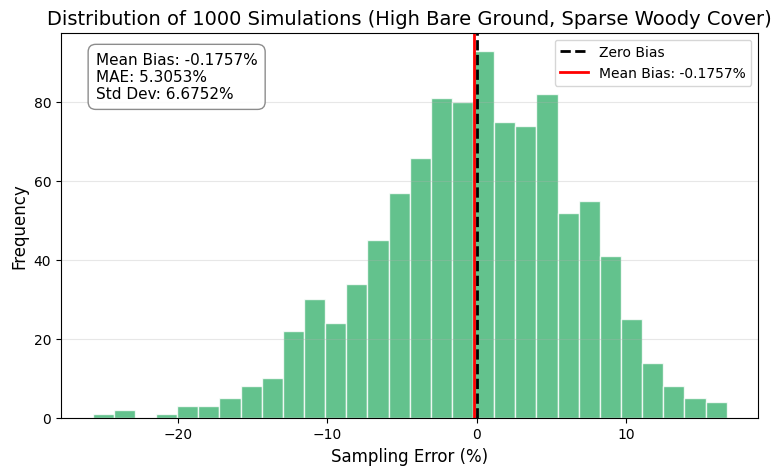

--- STATISTICAL SUMMARY ---
Mean Bias: -0.1757%
Mean Absolute Error: 5.3053%
Standard Deviation: 6.6752%


In [3]:

def run_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the NRI sampling logic headless for 1000 iterations to verify accuracy."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)

    errors = []

    print(f"Crunching {num_iterations} simulations... please wait.")

    for i in range(num_iterations):
        # 1. Generate new shrubs (60 shrubs, 3m average radius)
        shrubs = generate_random_shrubs(60, plot_radius)
        shrub_union = unary_union(shrubs)

        # 2. Calculate True Bare Ground
        shrubs_in_plot = shrub_union.intersection(plot_circle)
        true_bare_area = plot_circle.area - shrubs_in_plot.area
        true_bg_pct = (true_bare_area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground (Continuous Line)
        total_intercept = 0
        for spoke in spokes:
            intersection = spoke.intersection(shrub_union)
            total_intercept += intersection.length

        sampled_bg_pct = (1 - (total_intercept / total_transect_length)) * 100

        # 4. Record Error
        errors.append(sampled_bg_pct - true_bg_pct)

    # --- Statistics ---
    mean_error = np.mean(errors)
    std_dev = np.std(errors)
    mae = np.mean(np.abs(errors)) # Mean Absolute Error

    # --- Visualize Results ---
    plt.figure(figsize=(9, 5))
    plt.hist(errors, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
    plt.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

    plt.title(f"Distribution of {num_iterations} Simulations (High Bare Ground, Sparse Woody Cover)", fontsize=14)
    plt.xlabel("Sampling Error (%)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

    # Draw Stats Box in the upper left corner
    stats_text = (
        f"Mean Bias: {mean_error:+.4f}%\n"
        f"MAE: {mae:.4f}%\n"
        f"Std Dev: {std_dev:.4f}%"
    )
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    from IPython.display import clear_output
    clear_output(wait=True)
    plt.show()

    # Print summary to the output cell below the figure as well
    print("--- STATISTICAL SUMMARY ---")
    print(f"Mean Bias: {mean_error:+.4f}%")
    print(f"Mean Absolute Error: {mae:.4f}%")
    print(f"Standard Deviation: {std_dev:.4f}%")

# Execute the 1000-run batch
run_thousand_simulations(1000)


# Low Bare Ground Functions and Widget

In [ ]:

# ==========================================
# BLOCK 3: Inverted Simulation (Low Bare Ground)
# ==========================================
class InvertedNRISimulation:
    def __init__(self):
        self.plot_radius = 55
        self.hub_radius = 5
        self.plot_circle = Point(0, 0).buffer(self.plot_radius)
        self.spokes = get_nri_spokes(self.hub_radius, self.plot_radius)
        self.total_transect_length = 3 * (self.plot_radius - self.hub_radius) # 150m
        self.patches = []
        self.patch_union = None

        self.out = widgets.Output()
        self.setup_ui()
        self.generate_new_shapes()

    def generate_new_shapes(self, b=None):
        """Creates entirely new bare ground patches."""
        # Re-using the same function, but treating them as dirt patches instead of shrubs
        self.patches = generate_random_shrubs(60, self.plot_radius)
        self.patch_union = unary_union(self.patches)
        self.update_plot()

    def randomize_positions(self, b=None):
        """Moves existing bare ground patches to new locations."""
        new_patches = []
        generation_radius = self.plot_radius + 5.0

        for patch in self.patches:
            cx, cy = patch.centroid.x, patch.centroid.y
            r = generation_radius * np.sqrt(np.random.uniform(0, 1))
            theta = np.random.uniform(0, 2 * np.pi)
            new_cx, new_cy = r * np.cos(theta), r * np.sin(theta)

            from shapely.affinity import translate
            new_patch = translate(patch, xoff=(new_cx - cx), yoff=(new_cy - cy))
            new_patches.append(new_patch)

        self.patches = new_patches
        self.patch_union = unary_union(self.patches)
        self.update_plot()

    def setup_ui(self):
        self.protocol_dropdown = widgets.Dropdown(
            options=[
                ('0m (Continuous Line)', 0.0),
                ('0.25m (Point Intercept)', 0.25),
                ('0.50m (Point Intercept)', 0.50),
                ('1.00m (Point Intercept)', 1.00),
                ('2.00m (Point Intercept)', 2.00)
            ],
            value=0.0,
            description='Protocol:'
        )
        self.protocol_dropdown.observe(lambda change: self.update_plot() if change['name'] == 'value' else None)

        self.btn_randomize = widgets.Button(description="Randomize Positions", button_style='info')
        self.btn_randomize.on_click(self.randomize_positions)

        self.btn_new_shapes = widgets.Button(description="Generate New Patches", button_style='warning')
        self.btn_new_shapes.on_click(self.generate_new_shapes)

        controls = widgets.HBox([self.protocol_dropdown, self.btn_randomize, self.btn_new_shapes])
        display(widgets.VBox([controls, self.out]))

    def update_plot(self):
        with self.out:
            clear_output(wait=True)
            interval = self.protocol_dropdown.value

            # 1. Calculate True Bare Ground (INVERTED LOGIC)
            # Now, the polygons themselves represent the Bare Ground
            patches_in_plot = self.patch_union.intersection(self.plot_circle)
            true_bg_pct = (patches_in_plot.area / self.plot_circle.area) * 100

            # 2. Plotting setup
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.set_aspect('equal')
            ax.set_facecolor('#f0f0f0')
            ax.axis('off')

            # Draw plot boundary as Herbaceous Cover (Green)
            plot_patch = plt.Circle((0, 0), self.plot_radius, color='darkseagreen', ec='black', lw=2)
            hub_patch = plt.Circle((0, 0), self.hub_radius, color='#e0e0e0', ec='black', lw=1, ls='--')
            ax.add_patch(plot_patch)
            ax.add_patch(hub_patch)

            # Draw Bare Ground Patches (Tan/Brown)
            if self.patch_union.geom_type == 'Polygon':
                geoms = [self.patch_union]
            else:
                geoms = self.patch_union.geoms

            for geom in geoms:
                x, y = geom.exterior.xy
                ax.fill(x, y, alpha=0.8, fc='tan', ec='saddlebrown', lw=1.5)

            # 3. Calculate Sampled Bare Ground & Draw Sampling Tools (INVERTED LOGIC)
            sampled_bg_pct = 0

            if interval == 0.0: # Continuous Line Intercept
                total_intercept = 0
                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='white', lw=2, zorder=3) # White line over green grass

                    intersection = spoke.intersection(self.patch_union)
                    total_intercept += intersection.length

                    if not intersection.is_empty:
                        if intersection.geom_type == 'LineString':
                            ix, iy = intersection.xy
                            ax.plot(ix, iy, color='red', lw=3, zorder=4)
                        elif intersection.geom_type == 'MultiLineString':
                            for line in intersection.geoms:
                                ix, iy = line.xy
                                ax.plot(ix, iy, color='red', lw=3, zorder=4)

                # INVERTED: Intercept length is now directly the bare ground
                sampled_bg_pct = (total_intercept / self.total_transect_length) * 100

            else: # Point Intercept
                total_points = 0
                bare_points = 0

                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='whitesmoke', lw=1, zorder=2)

                for spoke in self.spokes:
                    for d in np.arange(0, 50.001, interval):
                        pt = spoke.interpolate(d)
                        total_points += 1

                        if self.patch_union.contains(pt):
                            ax.plot(pt.x, pt.y, 'ko', markersize=4, zorder=4) # Bare ground hit (Black)
                            bare_points += 1
                        else:
                            ax.plot(pt.x, pt.y, 'go', markersize=3, zorder=4) # Herbaceous hit (Green)

                sampled_bg_pct = (bare_points / total_points) * 100 if total_points > 0 else 0

            # 4. Display Metrics
            error = sampled_bg_pct - true_bg_pct
            color = 'black'
            if abs(error) > 5: color = 'darkorange'
            if abs(error) > 10: color = 'red'

            title_text = (
                f"True Bare Ground: {true_bg_pct:.2f}%\n"
                f"Sampled Bare Ground: {sampled_bg_pct:.2f}%\n"
            )
            plt.title(title_text, fontsize=14, pad=15)
            plt.figtext(0.5, 0.05, f"Error (Bias): {error:+.2f}%", ha="center", fontsize=16, fontweight='bold', color=color)

            plt.xlim(-70, 70)
            plt.ylim(-70, 70)
            plt.tight_layout()
            plt.show()

inverted_simulation = InvertedNRISimulation()


### 0 cm interval figure

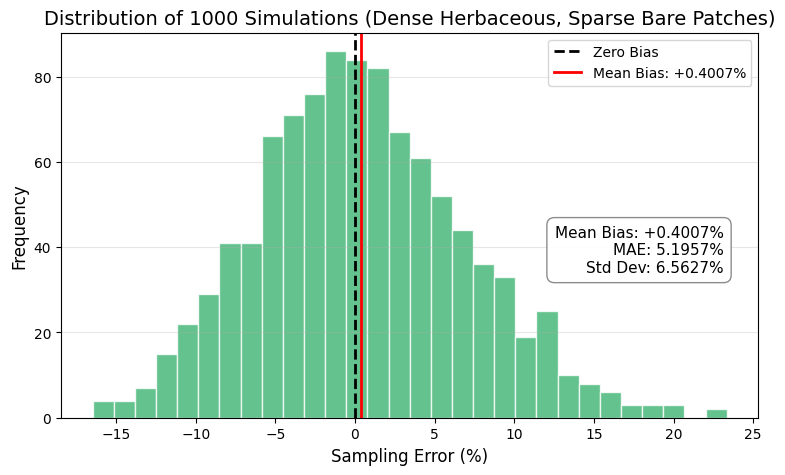

--- INVERTED STATISTICAL SUMMARY ---
Mean Bias: +0.4007%
Mean Absolute Error: 5.1957%
Standard Deviation: 6.5627%


In [6]:

# ==========================================
# BLOCK 4: Inverted Headless Validation
# ==========================================
def run_inverted_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the inverted logic headless for 1000 iterations to verify accuracy."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)

    errors = []

    print(f"Crunching {num_iterations} inverted simulations... please wait.")

    for i in range(num_iterations):
        # 1. Generate bare ground patches
        patches = generate_random_shrubs(60, plot_radius)
        patch_union = unary_union(patches)

        # 2. Calculate True Bare Ground (INVERTED LOGIC)
        patches_in_plot = patch_union.intersection(plot_circle)
        true_bg_pct = (patches_in_plot.area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground (INVERTED LOGIC)
        total_intercept = 0
        for spoke in spokes:
            intersection = spoke.intersection(patch_union)
            total_intercept += intersection.length

        sampled_bg_pct = (total_intercept / total_transect_length) * 100

        # 4. Record Error
        errors.append(sampled_bg_pct - true_bg_pct)

    # --- Statistics ---
    mean_error = np.mean(errors)
    std_dev = np.std(errors)
    mae = np.mean(np.abs(errors))

    # --- Visualize Results ---
    plt.figure(figsize=(9, 5))
    # Using a brown/tan color theme to represent the dirt patches
    plt.hist(errors, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
    plt.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

    plt.title(f"Distribution of {num_iterations} Simulations (Dense Herbaceous, Sparse Bare Patches)", fontsize=14)
    plt.xlabel("Sampling Error (%)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

    stats_text = (
        f"Mean Bias: {mean_error:+.4f}%\n"
        f"MAE: {mae:.4f}%\n"
        f"Std Dev: {std_dev:.4f}%"
    )
    plt.gca().text(0.95, 0.50, stats_text, transform=plt.gca().transAxes,
                   fontsize=11, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    from IPython.display import clear_output
    clear_output(wait=True)
    plt.show()

    print("--- INVERTED STATISTICAL SUMMARY ---")
    print(f"Mean Bias: {mean_error:+.4f}%")
    print(f"Mean Absolute Error: {mae:.4f}%")
    print(f"Standard Deviation: {std_dev:.4f}%")

run_inverted_thousand_simulations(1000)
